# FFCap u_target Sweep on Exynos 5422

Sweep the `u_target` parameter on the LITTLE cluster (big stays at 1.0)
to study the trade-off between acceptance rate and deadline misses.

`u_target` is the maximum per-task utilization **on that core type** that
the allocator will accept. `scaled_utilization` converts a task's reference
utilization to the cluster-local utilization, and `u_target` thresholds it.

All configurations use EDF + GRUB scheduling with GFB admission per cluster.

In [15]:
import os
import sys
import random
from pathlib import Path

sys.path.insert(0, str(Path("build/python").resolve()))

import pyschedsim as sim
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from scipy import stats
from drs import drs
from IPython.display import clear_output

# Enable autoreload so local module changes propagate in notebooks.
try:
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")
except Exception:
    pass

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
PLATFORM = "platforms/exynos5422.json"
N_SCENARIOS = 100
SUCCESS_RATE = 0.8
COMPRESSION_RATE = 0.5
NUM_HYPERPERIODS = 100  # repeat job pattern over 100 hyperperiods for longer simulations
MIN_JOBS = 700  # minimum total jobs per scenario
UTIL_PER_TASK_MIN = 0.001
UTIL_PER_TASK_MAX = 0.133

# Exynos 5422 capacity: 4 big (perf=1.0) + 4 LITTLE (perf=0.3334)
BIG_CAP = 4 * 1.0
LITTLE_CAP = 4 * 0.3334
PLATFORM_CAP = BIG_CAP + LITTLE_CAP  # 5.3336

UTIL_MIN = 4.1
UTIL_MAX = 6.5
UTIL_STEP = 0.2

# Need enough tasks so that N_TASKS * UTIL_PER_TASK_MAX >= UTIL_MAX
N_TASKS = int(np.ceil(UTIL_MAX / UTIL_PER_TASK_MAX))  # 49
print(f"N_TASKS = {N_TASKS}  (per-task util in [{UTIL_PER_TASK_MIN}, {UTIL_PER_TASK_MAX}])")

util_points = np.round(np.arange(UTIL_MIN, UTIL_MAX + UTIL_STEP / 2, UTIL_STEP), 4)

N_TASKS = 49  (per-task util in [0.001, 0.133])


## Compute the LITTLE cluster scale factor

`scaled_utilization(u_ref) = u_ref * scale_speed / perf`

A task with reference utilization `u_ref` is admitted on the LITTLE cluster
when `scaled_utilization(u_ref) <= u_target`, i.e.
`u_ref <= u_target / scale_factor`.

In [17]:
_engine = sim.Engine()
sim.load_platform(_engine, PLATFORM)
_platform = _engine.platform
_ref_freq_max = max(
    _platform.clock_domain(i).freq_max
    for i in range(_platform.clock_domain_count)
)

cluster_info = []
for i in range(_platform.clock_domain_count):
    cd = _platform.clock_domain(i)
    procs = cd.get_processors()
    if not procs:
        continue
    perf = procs[0].type().performance
    scale_speed = _ref_freq_max / cd.freq_max
    scale_factor = scale_speed / perf
    cluster_info.append({
        "cluster": i,
        "perf": perf,
        "freq_max": cd.freq_max,
        "scale_speed": round(scale_speed, 4),
        "scale_factor": round(scale_factor, 4),
        "n_procs": len(procs),
    })
    print(
        f"Cluster {i}: perf={perf}, freq_max={cd.freq_max}, "
        f"scale_speed={scale_speed:.4f}, scale_factor={scale_factor:.4f}"
    )

del _engine, _platform

LITTLE_SCALE = max(c["scale_factor"] for c in cluster_info if c["perf"] < 1.0)
print(f"\nLITTLE scale factor: {LITTLE_SCALE}")
print(f"u_target=0.5 → max ref util on LITTLE: {0.5 / LITTLE_SCALE:.4f}")
print(f"u_target=1.0 → max ref util on LITTLE: {1.0 / LITTLE_SCALE:.4f}")

Cluster 0: perf=1.0, freq_max=2100.0, scale_speed=1.0000, scale_factor=1.0000
Cluster 1: perf=0.3334, freq_max=1400.0, scale_speed=1.5000, scale_factor=4.4991

LITTLE scale factor: 4.4991
u_target=0.5 → max ref util on LITTLE: 0.1111
u_target=1.0 → max ref util on LITTLE: 0.2223


## Simulation helpers

In [18]:
def run_one(taskset: dict, little_u_target: float) -> dict:
    """Run a single FFCap simulation with the given u_target on the LITTLE cluster."""
    engine = sim.Engine()
    sim.load_platform(engine, PLATFORM)
    scenario = sim.load_scenario(taskset["path"])

    tasks = sim.inject_scenario(engine, scenario)
    for i, task in enumerate(tasks):
        sim.schedule_arrivals(engine, task, scenario.tasks[i].jobs)
    engine.platform.finalize()

    platform = engine.platform
    ref_freq_max = max(
        platform.clock_domain(i).freq_max
        for i in range(platform.clock_domain_count)
    )

    clusters = []
    for i in range(platform.clock_domain_count):
        cd = platform.clock_domain(i)
        procs = cd.get_processors()
        if not procs:
            continue
        sched = sim.EdfScheduler(engine, procs)
        sched.enable_grub()
        sched.set_admission_test(sim.AdmissionTest.GFB)
        perf = procs[0].type().performance
        cluster = sim.Cluster(cd, sched, perf, ref_freq_max)
        if perf < 1.0:
            cluster.set_u_target(little_u_target)
        clusters.append(cluster)

    _alloc = sim.FFCapAllocator(engine, clusters)

    writer = sim.MemoryTraceWriter()
    engine.set_trace_writer(writer)
    engine.run()

    metrics = writer.compute_metrics()
    total_arrivals = metrics.total_jobs + metrics.rejected_arrivals

    return {
        "total_util": taskset["total_util"],
        "seed": taskset["seed"],
        "u_target": round(little_u_target, 4),
        "total_jobs": metrics.total_jobs,
        "completed_jobs": metrics.completed_jobs,
        "deadline_misses": metrics.deadline_misses,
        "rejected_arrivals": metrics.rejected_arrivals,
        "total_arrivals": total_arrivals,
    }


def run_allocator_variant(taskset: dict, adaptive: bool) -> dict:
    """Run either FF Cap (u_target=1.0) or the adaptive linear allocator on one taskset."""
    engine = sim.Engine()
    sim.load_platform(engine, PLATFORM)
    scenario = sim.load_scenario(taskset["path"])

    tasks = sim.inject_scenario(engine, scenario)
    for i, task in enumerate(tasks):
        sim.schedule_arrivals(engine, task, scenario.tasks[i].jobs)
    engine.platform.finalize()

    platform = engine.platform
    ref_freq_max = max(
        platform.clock_domain(i).freq_max
        for i in range(platform.clock_domain_count)
    )

    clusters = []
    for i in range(platform.clock_domain_count):
        cd = platform.clock_domain(i)
        procs = cd.get_processors()
        if not procs:
            continue
        sched = sim.EdfScheduler(engine, procs)
        sched.enable_grub()
        sched.set_admission_test(sim.AdmissionTest.GFB)
        perf = procs[0].type().performance
        cluster = sim.Cluster(cd, sched, perf, ref_freq_max)
        if perf < 1.0:
            cluster.set_u_target(1.0)
        clusters.append(cluster)

    if adaptive:
        allocator = sim.FFCapAdaptiveLinearAllocator(engine, clusters)
        allocator.set_expected_total_util(taskset["total_util"])
        allocator_name = "ff_cap_adaptive_linear"
    else:
        allocator = sim.FFCapAllocator(engine, clusters)
        allocator_name = "ff_cap_u_target_1_0"

    writer = sim.MemoryTraceWriter()
    engine.set_trace_writer(writer)
    engine.run()

    metrics = writer.compute_metrics()
    total_arrivals = metrics.total_jobs + metrics.rejected_arrivals

    return {
        "total_util": taskset["total_util"],
        "seed": taskset["seed"],
        "allocator": allocator_name,
        "total_jobs": metrics.total_jobs,
        "completed_jobs": metrics.completed_jobs,
        "deadline_misses": metrics.deadline_misses,
        "rejected_arrivals": metrics.rejected_arrivals,
        "total_arrivals": total_arrivals,
    }

## Bounded taskset generation

Generate tasksets with per-task utilization bounded in
[`UTIL_PER_TASK_MIN`, `UTIL_PER_TASK_MAX`] using DRS + `from_utilizations`,
then write each scenario (with jobs) to disk:

```
tasksets/<util_x10>/<idx>.json
```

In [90]:
TASKSET_DIR = "tasksets"


def generate_utilizations(n_tasks: int, total_util: float, seed: int) -> list[float]:
    """Generate per-task utilizations summing to total_util using DRS, each in [UTIL_PER_TASK_MIN, UTIL_PER_TASK_MAX]."""
    random.seed(seed)
    return drs(
        n_tasks, total_util,
        upper_bounds=[UTIL_PER_TASK_MAX] * n_tasks,
        lower_bounds=[UTIL_PER_TASK_MIN] * n_tasks,
    )


tasksets = []
for j, util in enumerate(util_points):
    folder = os.path.join(TASKSET_DIR, str(int(round(util * 10))))
    os.makedirs(folder, exist_ok=True)
    for scenario_idx in range(N_SCENARIOS):
        seed = int(round(util * 10000)) * 10000 + scenario_idx
        utils = generate_utilizations(N_TASKS, util, seed)
        scenario = sim.from_utilizations(utils, SUCCESS_RATE, COMPRESSION_RATE, seed, NUM_HYPERPERIODS, MIN_JOBS)
        path = os.path.join(folder, f"{scenario_idx + 1}.json")
        sim.write_scenario(scenario, path)
        tasksets.append({
            "total_util": round(float(util), 4),
            "seed": seed,
            "utilizations": [float(u) for u in utils],
            "path": path,
        })
    clear_output(wait=True)
    print(f"  U={util:.1f} → {folder}/  ({j + 1}/{len(util_points)})")

print(f"\nGenerated {len(tasksets)} tasksets in {TASKSET_DIR}/")

  U=6.5 → tasksets/65/  (13/13)

Generated 1300 tasksets in tasksets/


### Bounded utilization distribution

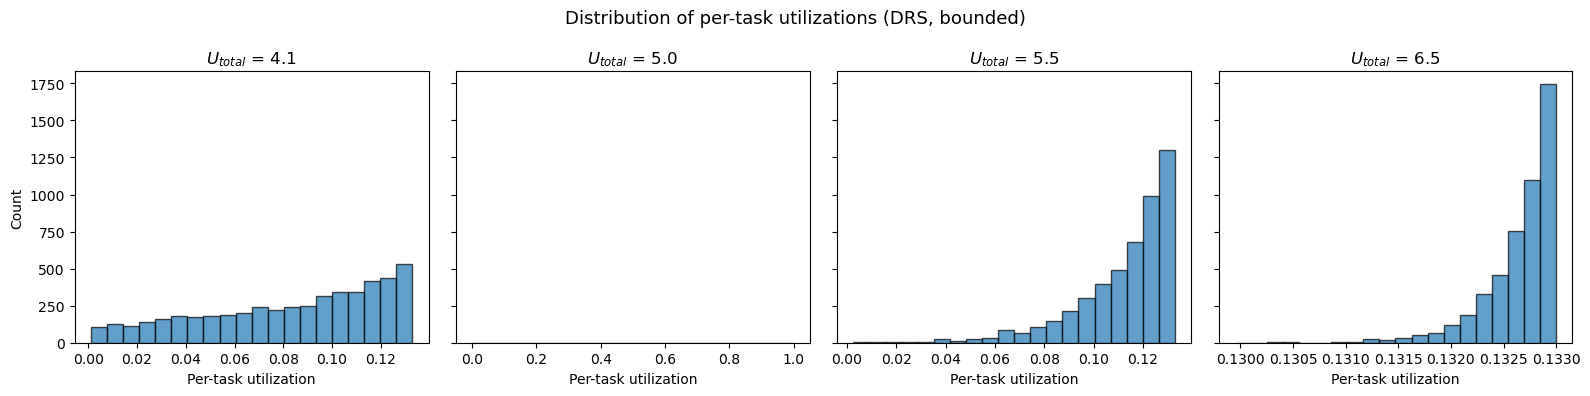

In [91]:
sample_points = [4.1, 5.0, 5.5, round(UTIL_MAX, 1)]
fig, axes = plt.subplots(1, len(sample_points), figsize=(16, 4), sharey=True)

for ax, target in zip(axes, sample_points):
    target_r = round(target, 4)
    all_utils = [u for t in tasksets if t["total_util"] == target_r for u in t["utilizations"]]
    ax.hist(all_utils, bins=20, edgecolor="black", alpha=0.7)
    ax.set_title(f"$U_{{total}}$ = {target:.1f}")
    ax.set_xlabel("Per-task utilization")

axes[0].set_ylabel("Count")
fig.suptitle("Distribution of per-task utilizations (DRS, bounded)", fontsize=13)
plt.tight_layout()
plt.show()

## Simulation — fine-grained u_target sweep

Sweep u_target from 0.04 to 0.65 in steps of 0.0025 for fine granularity.

In [7]:
U_TARGET_FINE = np.round(np.arange(0.04, 0.65 + 0.0025, 0.0025), 4)
print(f"Fine sweep: {len(U_TARGET_FINE)} u_target values from {U_TARGET_FINE[0]} to {U_TARGET_FINE[-1]}")
print(f"Total simulations: {len(U_TARGET_FINE)} × {len(tasksets)} = {len(U_TARGET_FINE) * len(tasksets)}")

Fine sweep: 245 u_target values from 0.04 to 0.65
Total simulations: 245 × 1300 = 318500


In [8]:
rows = []
for ut_idx, u_target in enumerate(U_TARGET_FINE):
    for j, util in enumerate(util_points):
        batch = [t for t in tasksets if t["total_util"] == round(float(util), 4)]
        for t in batch:
            rows.append(run_one(t, float(u_target)))
    clear_output(wait=True)
    print(f"u_target={u_target:.4f} complete ({ut_idx + 1}/{len(U_TARGET_FINE)})")

df = pl.DataFrame(rows)

u_target=0.6500 complete (245/245)


## Results

In [9]:
summary = (
    df.group_by(["u_target", "total_util"])
    .agg(
        deadline_miss_ratio=(pl.col("deadline_misses") > 0).mean(),
        acceptance_rate=1.0
        - pl.col("rejected_arrivals").sum() / pl.col("total_arrivals").sum(),
    )
    .sort(["u_target", "total_util"])
)

### Acceptance rate vs u_target per utilization point

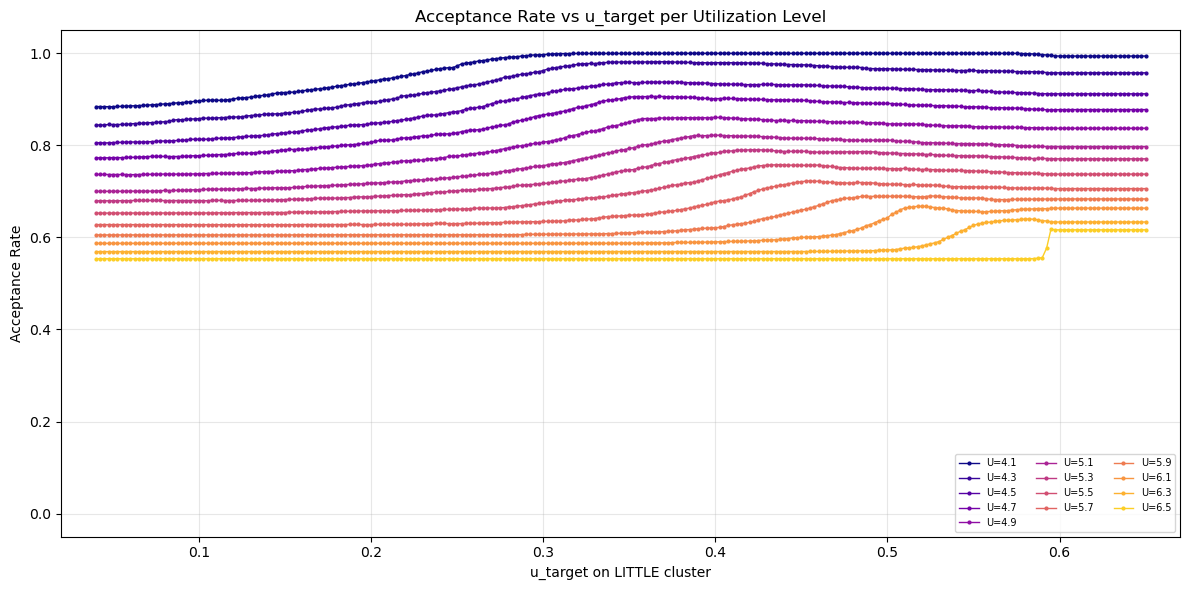

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

colors_util = cm.plasma(np.linspace(0, 0.9, len(util_points)))
for idx, util in enumerate(util_points):
    data = summary.filter(pl.col("total_util") == round(float(util), 4)).sort("u_target")
    ax.plot(
        data["u_target"], data["acceptance_rate"],
        marker=".", color=colors_util[idx],
        label=f"U={util:.1f}", markersize=4, linewidth=1,
    )

ax.set_xlabel("u_target on LITTLE cluster")
ax.set_ylabel("Acceptance Rate")
ax.set_title("Acceptance Rate vs u_target per Utilization Level")
ax.legend(fontsize=7, ncol=3, loc="lower right")
ax.grid(True, alpha=0.3)
ax.set_xlim(U_TARGET_FINE[0] - 0.02, U_TARGET_FINE[-1] + 0.02)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

### Optimal u_target per utilization point

In [11]:
best = (
    summary.sort(["total_util", "acceptance_rate"], descending=[False, True])
    .group_by("total_util", maintain_order=True)
    .first()
    .sort("total_util")
)
best

total_util,u_target,deadline_miss_ratio,acceptance_rate
f64,f64,f64,f64
4.1,0.42,0.0,1.0
4.3,0.3725,0.0,0.981775
4.5,0.3775,0.0,0.937954
4.7,0.3625,0.0,0.906778
4.9,0.4,0.0,0.860723
…,…,…,…
5.7,0.455,0.0,0.722869
5.9,0.525,0.0,0.690278
6.1,0.5175,0.0,0.667617


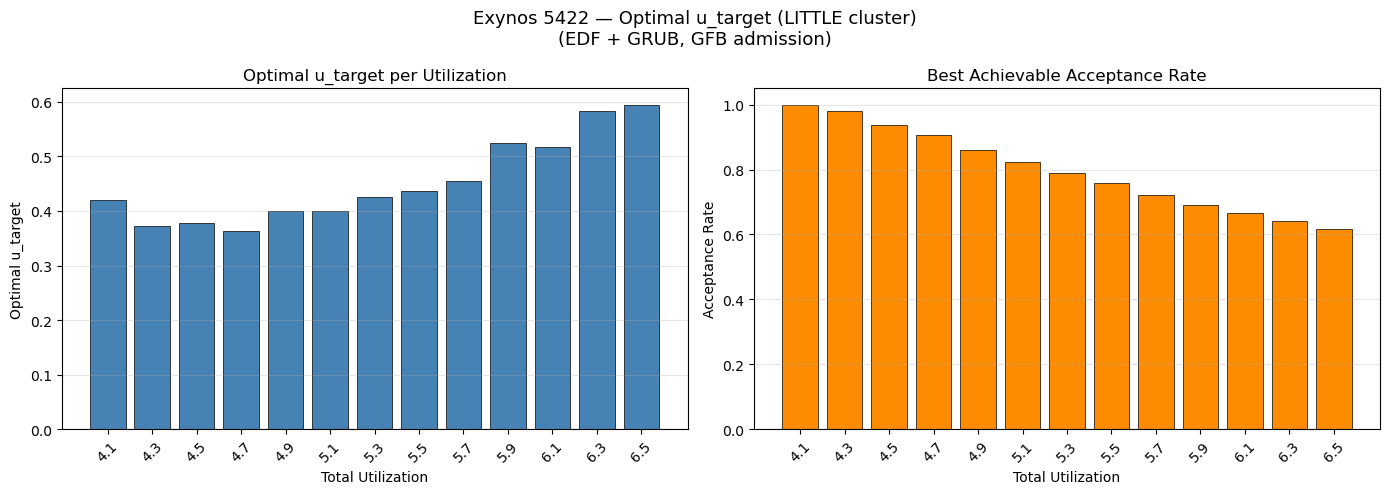

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    [f"{u:.1f}" for u in best["total_util"]],
    best["u_target"],
    color="steelblue", edgecolor="black", linewidth=0.5,
)
axes[0].set_xlabel("Total Utilization")
axes[0].set_ylabel("Optimal u_target")
axes[0].set_title("Optimal u_target per Utilization")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, alpha=0.3, axis="y")

axes[1].bar(
    [f"{u:.1f}" for u in best["total_util"]],
    best["acceptance_rate"],
    color="darkorange", edgecolor="black", linewidth=0.5,
)
axes[1].set_xlabel("Total Utilization")
axes[1].set_ylabel("Acceptance Rate")
axes[1].set_title("Best Achievable Acceptance Rate")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, alpha=0.3, axis="y")
axes[1].set_ylim(0, 1.05)

fig.suptitle(
    "Exynos 5422 — Optimal u_target (LITTLE cluster)\n"
    "(EDF + GRUB, GFB admission)",
    fontsize=13,
)
plt.tight_layout()
plt.show()

### Summary: optimal u_target across all utilization points

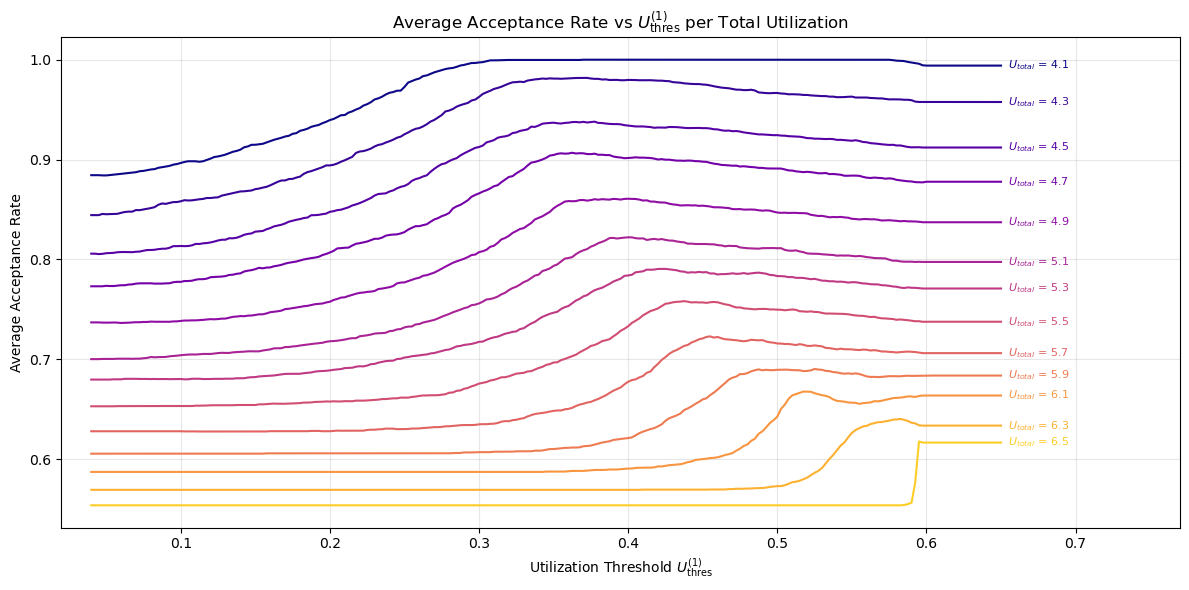

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

colors_util = cm.plasma(np.linspace(0, 0.9, len(util_points)))
for idx, util in enumerate(util_points):
    data = summary.filter(pl.col("total_util") == round(float(util), 4)).sort("u_target")
    mean_acc = (
        data.group_by("u_target", maintain_order=True)
        .agg(mean_acceptance=pl.col("acceptance_rate").mean())
    )
    color = colors_util[idx]
    ax.plot(
        mean_acc["u_target"], mean_acc["mean_acceptance"],
        color=color, linewidth=1.5,
    )
    # Label on the right side of each curve
    last_y = mean_acc["mean_acceptance"][-1]
    ax.annotate(
        f"$U_{{total}}$ = {util:.1f}",
        xy=(float(U_TARGET_FINE[-1]), float(last_y)),
        xytext=(5, 0), textcoords="offset points",
        fontsize=8, color=color, va="center",
    )

ax.set_xlabel(r"Utilization Threshold $U_{\mathrm{thres}}^{(1)}$")
ax.set_ylabel("Average Acceptance Rate")
ax.set_title("Average Acceptance Rate vs $U_{\\mathrm{thres}}^{(1)}$ per Total Utilization")
ax.grid(True, alpha=0.3)
ax.set_xlim(U_TARGET_FINE[0] - 0.02, U_TARGET_FINE[-1] + 0.12)
plt.tight_layout()
plt.show()

## Unbounded taskset generation

Generate a second dataset using DRS with loose bounds (0 to 1.0) so
individual tasks can have any utilization in [UTIL_PER_TASK_MIN, 1.0].
DRS gives near-uniform marginals when n_tasks ≈ total_util / midpoint,
so we compute the number of tasks per utilization step accordingly.

In [19]:
TASKSET_DIR_UNBOUNDED = "tasksets_unbounded"
N_SCENARIOS_UNBOUNDED = 200
UTIL_MIN_UNBOUNDED = 1.0
UTIL_STEP_UNBOUNDED = 0.1
UTIL_UNBOUNDED_LO = UTIL_PER_TASK_MIN
UTIL_UNBOUNDED_HI = 1.0
UTIL_UNBOUNDED_MID = (UTIL_UNBOUNDED_LO + UTIL_UNBOUNDED_HI) / 2
util_points_unbounded = np.round(
    np.arange(UTIL_MIN_UNBOUNDED, UTIL_MAX + UTIL_STEP_UNBOUNDED / 2, UTIL_STEP_UNBOUNDED), 4
)

tasksets_unbounded = []
for j, util in enumerate(util_points_unbounded):
    n_tasks_u = max(int(np.ceil(util / UTIL_UNBOUNDED_HI)),
                    round(util / UTIL_UNBOUNDED_MID))
    print(n_tasks_u)
    folder = os.path.join(TASKSET_DIR_UNBOUNDED, str(int(round(util * 10))))
    os.makedirs(folder, exist_ok=True)
    for scenario_idx in range(N_SCENARIOS_UNBOUNDED):
        seed = int(round(util * 10000)) * 20000 + scenario_idx
        random.seed(seed)
        utils = drs(
            n_tasks_u, util,
            upper_bounds=[UTIL_UNBOUNDED_HI] * n_tasks_u,
            lower_bounds=[UTIL_UNBOUNDED_LO] * n_tasks_u,
        )
        scenario = sim.from_utilizations(utils, SUCCESS_RATE, COMPRESSION_RATE, seed, NUM_HYPERPERIODS, MIN_JOBS)
        path = os.path.join(folder, f"{scenario_idx + 1}.json")
        sim.write_scenario(scenario, path)
        tasksets_unbounded.append({
            "total_util": round(float(util), 4),
            "seed": seed,
            "utilizations": [float(u) for u in utils],
            "path": path,
        })
    clear_output(wait=True)
    print(f"  U={util:.1f} → {folder}/  ({j + 1}/{len(util_points_unbounded)})")

print(f"\nGenerated {len(tasksets_unbounded)} unbounded tasksets in {TASKSET_DIR_UNBOUNDED}/")

  U=6.5 → tasksets_unbounded/65/  (56/56)

Generated 11200 unbounded tasksets in tasksets_unbounded/


### Unbounded utilization distribution

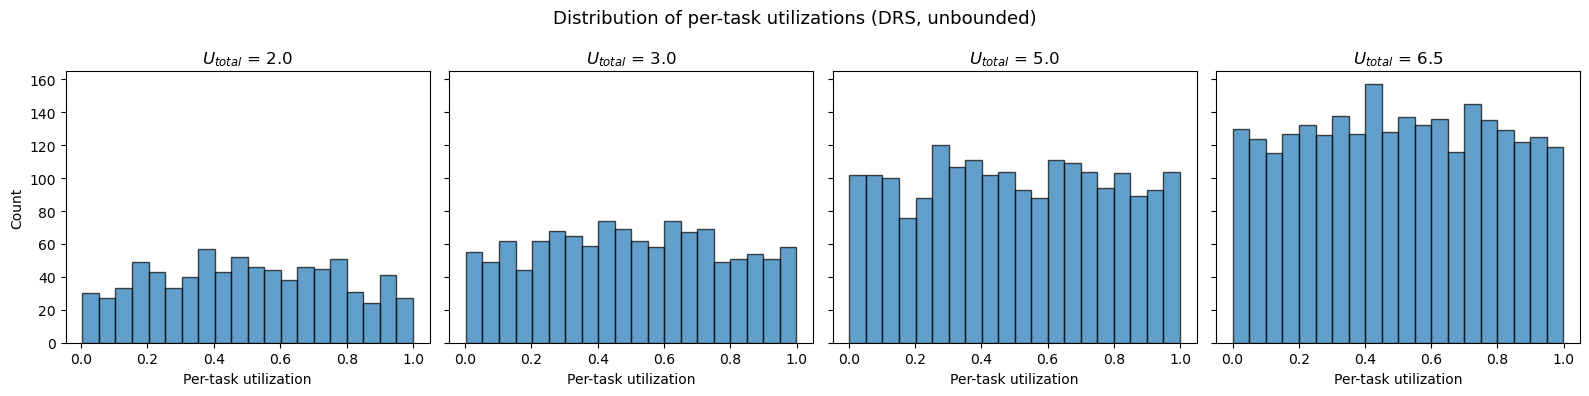

In [20]:
sample_points_unbounded = [2.0, 3.0, 5.0, round(UTIL_MAX, 1)]
fig, axes = plt.subplots(1, len(sample_points_unbounded), figsize=(16, 4), sharey=True)

for ax, target in zip(axes, sample_points_unbounded):
    target_r = round(target, 4)
    all_utils = [u for t in tasksets_unbounded if t["total_util"] == target_r for u in t["utilizations"]]
    ax.hist(all_utils, bins=20, edgecolor="black", alpha=0.7)
    ax.set_title(f"$U_{{total}}$ = {target:.1f}")
    ax.set_xlabel("Per-task utilization")

axes[0].set_ylabel("Count")
fig.suptitle("Distribution of per-task utilizations (DRS, unbounded)", fontsize=13)
plt.tight_layout()
plt.show()

## Adaptive vs FFCap (u_target = 1.0) — unbounded tasksets

Compare the acceptance rate of the adaptive allocator against classic
FFCap with a permissive LITTLE-cluster threshold (`u_target = 1.0`)
on the unbounded tasksets.

In [21]:
comparison_rows = []
for name, is_adaptive in [("ff_cap_adaptive_linear", True), ("ff_cap_u_target_1_0", False)]:
    for idx, taskset in enumerate(tasksets_unbounded):
        comparison_rows.append(run_allocator_variant(taskset, is_adaptive))
        if (idx + 1) % 50 == 0 or (idx + 1) == len(tasksets_unbounded):
            clear_output(wait=True)
            print(f"  {name}: {idx + 1}/{len(tasksets_unbounded)} tasksets")
    print(f"{name}: complete\n")

comparison_df = pl.DataFrame(comparison_rows)

  ff_cap_u_target_1_0: 11200/11200 tasksets
ff_cap_u_target_1_0: complete



In [22]:
# Per-scenario acceptance rate: accepted / total_arrivals for each (seed, total_util)
comparison_per_scenario = (
    comparison_df.with_columns(
        (pl.col("total_arrivals") - pl.col("rejected_arrivals"))
        .truediv(pl.col("total_arrivals"))
        .alias("acceptance_rate")
    )
)

# Pivot so we have one row per scenario with both allocators side by side
adaptive_sc = (
    comparison_per_scenario
    .filter(pl.col("allocator") == "ff_cap_adaptive_linear")
    .select(["total_util", "seed", pl.col("acceptance_rate").alias("acc_adaptive")])
)
baseline_sc = (
    comparison_per_scenario
    .filter(pl.col("allocator") == "ff_cap_u_target_1_0")
    .select(["total_util", "seed", pl.col("acceptance_rate").alias("acc_baseline")])
)
paired = (
    adaptive_sc.join(baseline_sc, on=["total_util", "seed"])
    .with_columns((pl.col("acc_adaptive") - pl.col("acc_baseline")).alias("gain"))
    .sort(["total_util", "seed"])
)

### Statistical significance (Wilcoxon signed-rank test)

For each utilization point, test whether the adaptive allocator's
per-scenario acceptance rate differs significantly from FFCap.

In [23]:
def sig_label(p: float) -> str:
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


sig_rows = []
for util in sorted(paired["total_util"].unique().to_list()):
    gains = paired.filter(pl.col("total_util") == util)["gain"].to_numpy()
    mean_gain = float(gains.mean())
    if np.all(gains == 0):
        p_val = 1.0
    else:
        _, p_val = stats.wilcoxon(gains, alternative="two-sided")
    sig_rows.append({
        "total_util": util,
        "mean_gain_pct": round(mean_gain * 100, 4),
        "p_value": float(p_val),
        "significance": sig_label(p_val),
    })

sig_df = pl.DataFrame(sig_rows)
sig_df

total_util,mean_gain_pct,p_value,significance
f64,f64,f64,str
1.0,0.0,1.0,"""ns"""
1.1,0.0,1.0,"""ns"""
1.2,0.0,1.0,"""ns"""
1.3,0.1429,0.317311,"""ns"""
1.4,0.0,1.0,"""ns"""
…,…,…,…
6.1,1.4773,0.000038,"""***"""
6.2,1.1851,0.00286,"""**"""
6.3,3.0671,7.0454e-10,"""***"""


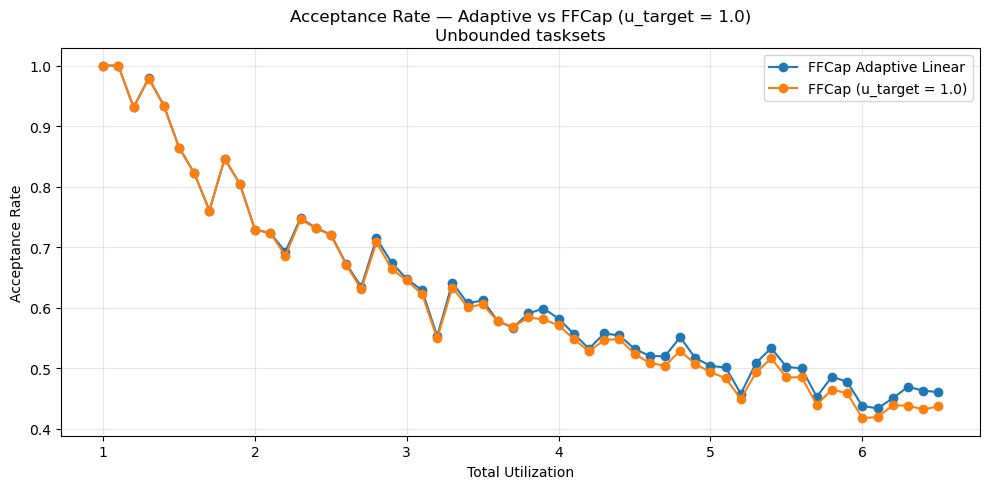

In [24]:
label_map = {
    "ff_cap_adaptive_linear": "FFCap Adaptive Linear",
    "ff_cap_u_target_1_0": "FFCap (u_target = 1.0)",
}

comparison_summary = (
    comparison_df.group_by(["allocator", "total_util"])
    .agg(
        acceptance_rate=1.0
        - pl.col("rejected_arrivals").sum() / pl.col("total_arrivals").sum(),
    )
    .sort(["allocator", "total_util"])
)

fig, ax = plt.subplots(figsize=(10, 5))
for name, label in label_map.items():
    data = comparison_summary.filter(pl.col("allocator") == name).sort("total_util")
    ax.plot(
        data["total_util"], data["acceptance_rate"],
        marker="o", linewidth=1.5, label=label,
    )

ax.set_xlabel("Total Utilization")
ax.set_ylabel("Acceptance Rate")
ax.set_title("Acceptance Rate — Adaptive vs FFCap (u_target = 1.0)\nUnbounded tasksets")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Acceptance rate gain (Adaptive − FFCap)

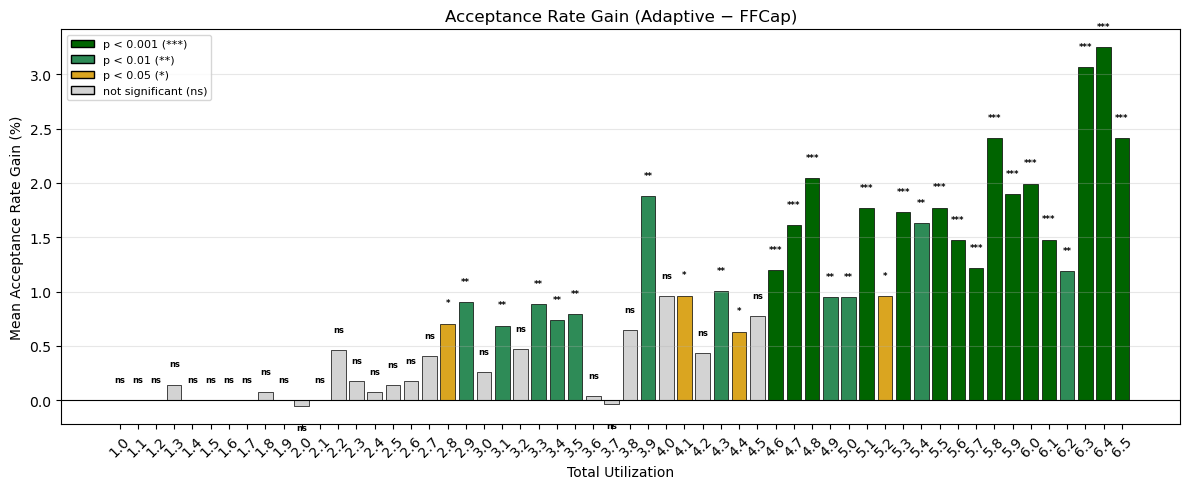

In [25]:
utils_arr = sig_df["total_util"].to_numpy()
gains_arr = sig_df["mean_gain_pct"].to_numpy()
sig_labels = sig_df["significance"].to_list()

SIG_COLORS = {"***": "darkgreen", "**": "seagreen", "*": "goldenrod", "ns": "lightgray"}

fig, ax = plt.subplots(figsize=(12, 5))
colors = [SIG_COLORS[s] for s in sig_labels]
bars = ax.bar(
    [f"{u:.1f}" for u in utils_arr], gains_arr,
    color=colors, edgecolor="black", linewidth=0.5,
)

for bar, label in zip(bars, sig_labels):
    y = bar.get_height()
    va = "bottom" if y >= 0 else "top"
    offset = 0.15 if y >= 0 else -0.15
    ax.text(bar.get_x() + bar.get_width() / 2, y + offset, label,
            ha="center", va=va, fontsize=6, fontweight="bold")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Total Utilization")
ax.set_ylabel("Mean Acceptance Rate Gain (%)")
ax.set_title("Acceptance Rate Gain (Adaptive − FFCap)")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, axis="y", alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="darkgreen", edgecolor="black", label="p < 0.001 (***)"),
    Patch(facecolor="seagreen", edgecolor="black", label="p < 0.01 (**)"),
    Patch(facecolor="goldenrod", edgecolor="black", label="p < 0.05 (*)"),
    Patch(facecolor="lightgray", edgecolor="black", label="not significant (ns)"),
]
ax.legend(handles=legend_elements, fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## Energy consumption — CSF vs FFA

Compare energy consumption of the CSF (Core Scaling First) and FFA
(Feedback-based Frequency Adaptation) DVFS/DPM policies on the
unbounded tasksets, using FFCap allocation with `u_target = 1.0`.

In [32]:
def run_energy_variant(taskset: dict, dvfs_policy: str) -> dict:
    """Run FFCap with a DVFS/DPM policy and return energy metrics."""
    engine = sim.Engine()
    sim.load_platform(engine, PLATFORM)
    engine.enable_energy_tracking(True)
    scenario = sim.load_scenario(taskset["path"])

    tasks = sim.inject_scenario(engine, scenario)
    for i, task in enumerate(tasks):
        sim.schedule_arrivals(engine, task, scenario.tasks[i].jobs)
    engine.platform.finalize()

    platform = engine.platform
    ref_freq_max = max(
        platform.clock_domain(i).freq_max
        for i in range(platform.clock_domain_count)
    )

    clusters = []
    for i in range(platform.clock_domain_count):
        cd = platform.clock_domain(i)
        procs = cd.get_processors()
        if not procs:
            continue
        sched = sim.EdfScheduler(engine, procs)
        sched.enable_grub()
        sched.set_admission_test(sim.AdmissionTest.GFB)
        if dvfs_policy == "csf":
            sched.enable_csf(cooldown=0.0)
        elif dvfs_policy == "ffa":
            sched.enable_ffa(cooldown=0.0)
        elif dvfs_policy == "grub_pa":
            sched.enable_power_aware_dvfs(cooldown=0.0)
        elif dvfs_policy == "grub":
            pass  # baseline: no DVFS, no DPM
        perf = procs[0].type().performance
        cluster = sim.Cluster(cd, sched, perf, ref_freq_max)
        if perf < 1.0:
            cluster.set_u_target(1.0)
        clusters.append(cluster)

    _alloc = sim.FFCapAllocator(engine, clusters)

    writer = sim.MemoryTraceWriter()
    engine.set_trace_writer(writer)
    engine.run()

    sim_duration_s = engine.time
    metrics = writer.compute_metrics()
    total_arrivals = metrics.total_jobs + metrics.rejected_arrivals
    avg_power_mw = metrics.total_energy_mj / sim_duration_s if sim_duration_s > 0 else 0.0

    return {
        "total_util": taskset["total_util"],
        "seed": taskset["seed"],
        "policy": dvfs_policy,
        "total_energy_mj": metrics.total_energy_mj,
        "sim_duration_s": sim_duration_s,
        "avg_power_mw": avg_power_mw,
        "total_jobs": metrics.total_jobs,
        "completed_jobs": metrics.completed_jobs,
        "deadline_misses": metrics.deadline_misses,
        "rejected_arrivals": metrics.rejected_arrivals,
        "total_arrivals": total_arrivals,
    }

In [33]:
ENERGY_POLICIES = [("grub", "GRUB"), ("grub_pa", "GRUB-PA"), ("csf", "CSF"), ("ffa", "FFA")]

energy_rows = []
for policy_key, policy_name in ENERGY_POLICIES:
    for idx, taskset in enumerate(tasksets_unbounded):
        energy_rows.append(run_energy_variant(taskset, policy_key))
        if (idx + 1) % 50 == 0 or (idx + 1) == len(tasksets_unbounded):
            clear_output(wait=True)
            print(f"  {policy_name}: {idx + 1}/{len(tasksets_unbounded)} tasksets")
    print(f"{policy_name}: complete\n")

energy_df = pl.DataFrame(energy_rows)

  FFA: 11200/11200 tasksets
FFA: complete



In [34]:
energy_summary = (
    energy_df.group_by(["policy", "total_util"])
    .agg(
        mean_avg_power_mw=pl.col("avg_power_mw").mean(),
        acceptance_rate=1.0
        - pl.col("rejected_arrivals").sum() / pl.col("total_arrivals").sum(),
        deadline_miss_rate=pl.col("deadline_misses").sum() / pl.col("total_jobs").sum(),
    )
    .sort(["policy", "total_util"])
)
energy_summary

policy,total_util,mean_avg_power_mw,acceptance_rate,deadline_miss_rate
str,f64,f64,f64,f64
"""csf""",1.0,1015.843764,1.0,0.0
"""csf""",1.1,1274.642355,1.0,0.0
"""csf""",1.2,1475.752243,0.92,0.0
"""csf""",1.3,907.875822,0.970719,0.0
"""csf""",1.4,969.020771,0.910891,0.0
…,…,…,…,…
"""grub_pa""",6.1,2838.676189,0.434588,0.0
"""grub_pa""",6.2,2792.973342,0.438407,0.0
"""grub_pa""",6.3,2866.39049,0.441399,0.0


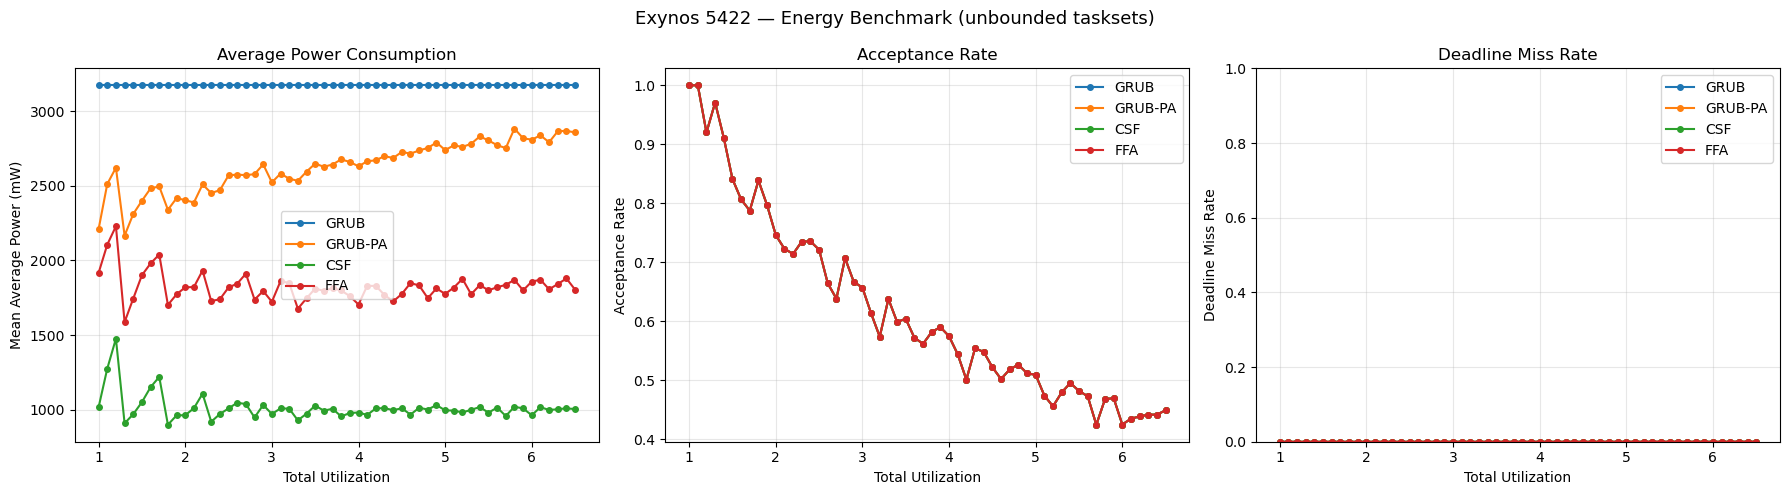

In [35]:
policy_labels = {"grub": "GRUB", "grub_pa": "GRUB-PA", "csf": "CSF", "ffa": "FFA"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Average power consumption
for policy_key, label in policy_labels.items():
    data = energy_summary.filter(pl.col("policy") == policy_key).sort("total_util")
    axes[0].plot(
        data["total_util"], data["mean_avg_power_mw"],
        marker="o", linewidth=1.5, markersize=4, label=label,
    )

axes[0].set_xlabel("Total Utilization")
axes[0].set_ylabel("Mean Average Power (mW)")
axes[0].set_title("Average Power Consumption")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Acceptance rate
for policy_key, label in policy_labels.items():
    data = energy_summary.filter(pl.col("policy") == policy_key).sort("total_util")
    axes[1].plot(
        data["total_util"], data["acceptance_rate"],
        marker="o", linewidth=1.5, markersize=4, label=label,
    )

axes[1].set_xlabel("Total Utilization")
axes[1].set_ylabel("Acceptance Rate")
axes[1].set_title("Acceptance Rate")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Deadline misses
for policy_key, label in policy_labels.items():
    data = energy_summary.filter(pl.col("policy") == policy_key).sort("total_util")
    axes[2].plot(
        data["total_util"], data["deadline_miss_rate"],
        marker="o", linewidth=1.5, markersize=4, label=label,
    )

axes[2].set_xlabel("Total Utilization")
axes[2].set_ylabel("Deadline Miss Rate")
axes[2].set_ylim(0, 1)
axes[2].set_title("Deadline Miss Rate")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.suptitle("Exynos 5422 — Energy Benchmark (unbounded tasksets)", fontsize=13)
plt.tight_layout()
plt.show()

## Mixed-profile taskset generation

Generate tasksets composed of three utilization classes to model a
heterogeneous workload:

| Share | Utilization range | Profile |
|-------|-------------------|---------|
| 40 %  | [0.01, 0.12]      | Light   |
| 20 %  | [0.25, 0.33]      | Medium  |
| 40 %  | [0.50, 0.80]      | Heavy   |

For each total utilization target, the budget is distributed across
classes proportionally to `n_class × midpoint`, then clamped to
feasible bounds and generated with DRS.

In [30]:
TASKSET_DIR_MIXED = "tasksets_mixed"
N_SCENARIOS_MIXED = 2000

# (fraction of tasks, lower bound, upper bound)
UTIL_CLASSES = [
    (0.40, 0.01, 0.10),  # light
    (0.20, 0.18, 0.22),  # medium
    (0.40, 0.50, 0.80),  # heavy
]

CLASS_MIDS = [(lo + hi) / 2 for _, lo, hi in UTIL_CLASSES]
FRAC_MID_SUM = sum(f * m for (f, _, _), m in zip(UTIL_CLASSES, CLASS_MIDS))


def compute_class_counts(total_util: float) -> list[int]:
    """Compute per-class task counts so the per-task average ≈ class midpoint.

    This gives DRS the best conditions for approximately uniform marginals.
    """
    return [max(1, round(total_util * f / FRAC_MID_SUM)) for f, _, _ in UTIL_CLASSES]


for util in [UTIL_MIN, (UTIL_MIN + UTIL_MAX) / 2, UTIL_MAX]:
    cc = compute_class_counts(util)
    print(f"U={util:.1f} → {sum(cc)} tasks: {cc}")
    for (frac, lo, hi), nc in zip(UTIL_CLASSES, cc):
        print(f"    {nc} tasks in [{lo}, {hi}] ({frac*100:.0f}%)")

U=4.1 → 13 tasks: [5, 3, 5]
    5 tasks in [0.01, 0.1] (40%)
    3 tasks in [0.18, 0.22] (20%)
    5 tasks in [0.5, 0.8] (40%)
U=5.3 → 17 tasks: [7, 3, 7]
    7 tasks in [0.01, 0.1] (40%)
    3 tasks in [0.18, 0.22] (20%)
    7 tasks in [0.5, 0.8] (40%)
U=6.5 → 20 tasks: [8, 4, 8]
    8 tasks in [0.01, 0.1] (40%)
    4 tasks in [0.18, 0.22] (20%)
    8 tasks in [0.5, 0.8] (40%)


In [31]:
def generate_mixed_utilizations(
    total_util: float,
    seed: int,
) -> list[float]:
    """Generate per-task utilizations for a mixed-profile taskset.

    The number of tasks per class is chosen so that the per-task average
    matches the class midpoint, giving DRS approximately uniform marginals.
    """
    random.seed(seed)
    cc = compute_class_counts(total_util)

    # Distribute total_util so per-task average ≈ class midpoint
    weights = [nc * mid for nc, mid in zip(cc, CLASS_MIDS)]
    total_weight = sum(weights)
    class_utils = [total_util * w / total_weight for w in weights]

    # Iteratively clamp and redistribute
    for _ in range(20):
        excess = 0.0
        unfixed = []
        for i, (nc, (_, lo, hi)) in enumerate(zip(cc, UTIL_CLASSES)):
            lo_sum, hi_sum = nc * lo, nc * hi
            if class_utils[i] < lo_sum:
                excess += class_utils[i] - lo_sum
                class_utils[i] = lo_sum
            elif class_utils[i] > hi_sum:
                excess += class_utils[i] - hi_sum
                class_utils[i] = hi_sum
            else:
                unfixed.append(i)
        if abs(excess) < 1e-10 or not unfixed:
            break
        for i in unfixed:
            class_utils[i] += excess / len(unfixed)

    # DRS per class (short-circuit when clamped to a boundary to avoid
    # division by zero inside DRS when sumu == sum(lower_bounds))
    all_utils = []
    for i, (nc, (_, lo, hi)) in enumerate(zip(cc, UTIL_CLASSES)):
        lo_sum, hi_sum = nc * lo, nc * hi
        if abs(class_utils[i] - lo_sum) < 1e-10:
            utils = [lo] * nc
        elif abs(class_utils[i] - hi_sum) < 1e-10:
            utils = [hi] * nc
        else:
            utils = drs(
                nc, class_utils[i],
                upper_bounds=[hi] * nc,
                lower_bounds=[lo] * nc,
            )
        all_utils.extend(utils)
    return all_utils


UTIL_MIN_MIXED = 2.0
UTIL_MAX_MIXED = 5.5
util_points_mixed = np.round(
    np.arange(UTIL_MIN_MIXED, UTIL_MAX_MIXED + UTIL_STEP / 2, UTIL_STEP), 4
)

tasksets_mixed = []
for j, util in enumerate(util_points_mixed):
    folder = os.path.join(TASKSET_DIR_MIXED, str(int(round(util * 10))))
    os.makedirs(folder, exist_ok=True)
    for scenario_idx in range(N_SCENARIOS_MIXED):
        seed = int(round(util * 10000)) * 30000 + scenario_idx
        utils = generate_mixed_utilizations(util, seed)
        scenario = sim.from_utilizations(utils, SUCCESS_RATE, COMPRESSION_RATE, seed, NUM_HYPERPERIODS, MIN_JOBS)
        path = os.path.join(folder, f"{scenario_idx + 1}.json")
        sim.write_scenario(scenario, path)
        tasksets_mixed.append({
            "total_util": round(float(util), 4),
            "seed": seed,
            "utilizations": [float(u) for u in utils],
            "path": path,
        })
    clear_output(wait=True)
    print(f"  U={util:.1f} → {folder}/  ({j + 1}/{len(util_points_mixed)})")

print(f"\nGenerated {len(tasksets_mixed)} mixed-profile tasksets in {TASKSET_DIR_MIXED}/")

  U=5.4 → tasksets_mixed/54/  (18/18)

Generated 36000 mixed-profile tasksets in tasksets_mixed/


### Mixed-profile utilization distribution

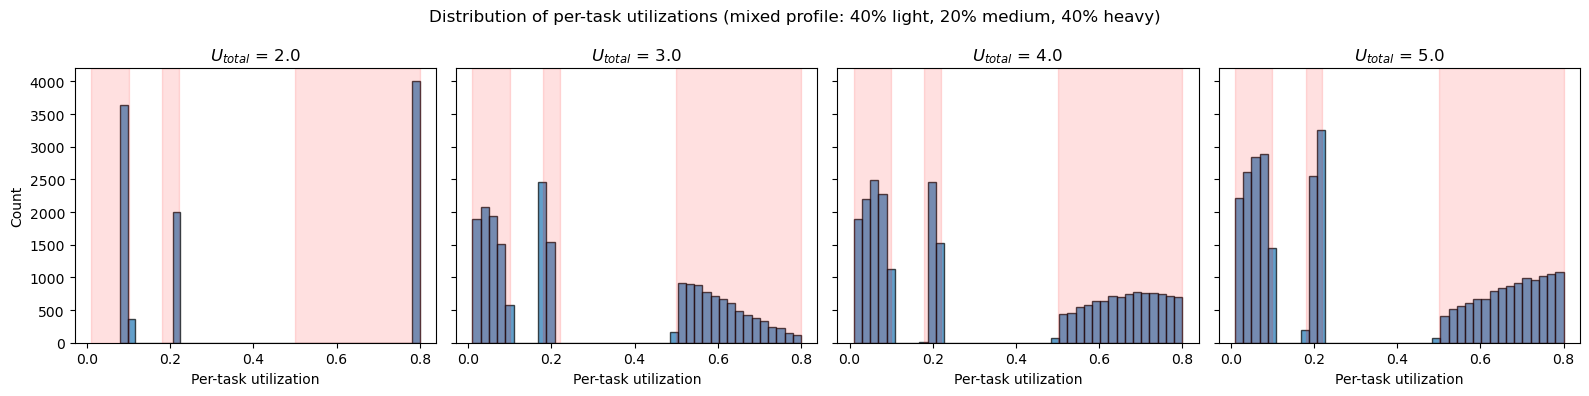

In [18]:
sample_points_mixed = [2.0, 3.0, 4.0, 5.0]
class_boundaries = [(lo, hi) for _, lo, hi in UTIL_CLASSES]

fig, axes = plt.subplots(1, len(sample_points_mixed), figsize=(16, 4), sharey=True)

for ax, target in zip(axes, sample_points_mixed):
    target_r = round(target, 4)
    all_utils = [
        u for t in tasksets_mixed if t["total_util"] == target_r
        for u in t["utilizations"]
    ]
    ax.hist(all_utils, bins=40, edgecolor="black", alpha=0.7)
    for lo, hi in class_boundaries:
        ax.axvspan(lo, hi, alpha=0.12, color="red")
    ax.set_title(f"$U_{{total}}$ = {target:.1f}")
    ax.set_xlabel("Per-task utilization")

axes[0].set_ylabel("Count")
fig.suptitle(
    "Distribution of per-task utilizations (mixed profile: "
    "40% light, 20% medium, 40% heavy)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Adaptive vs FFCap (u_target = 1.0) — mixed-profile tasksets

Same comparison as the unbounded section but on the mixed-profile
tasksets (40 % light / 20 % medium / 40 % heavy).

In [19]:
mixed_comparison_rows = []
for name, is_adaptive in [("ff_cap_adaptive_linear", True), ("ff_cap_u_target_1_0", False)]:
    for idx, taskset in enumerate(tasksets_mixed):
        mixed_comparison_rows.append(run_allocator_variant(taskset, is_adaptive))
        if (idx + 1) % 50 == 0 or (idx + 1) == len(tasksets_mixed):
            clear_output(wait=True)
            print(f"  {name}: {idx + 1}/{len(tasksets_mixed)} tasksets")
    print(f"{name}: complete\n")

mixed_comparison_df = pl.DataFrame(mixed_comparison_rows)

  ff_cap_u_target_1_0: 36000/36000 tasksets
ff_cap_u_target_1_0: complete



In [20]:
mixed_per_scenario = (
    mixed_comparison_df.with_columns(
        (pl.col("total_arrivals") - pl.col("rejected_arrivals"))
        .truediv(pl.col("total_arrivals"))
        .alias("acceptance_rate")
    )
)

mixed_adaptive_sc = (
    mixed_per_scenario
    .filter(pl.col("allocator") == "ff_cap_adaptive_linear")
    .select(["total_util", "seed", pl.col("acceptance_rate").alias("acc_adaptive")])
)
mixed_baseline_sc = (
    mixed_per_scenario
    .filter(pl.col("allocator") == "ff_cap_u_target_1_0")
    .select(["total_util", "seed", pl.col("acceptance_rate").alias("acc_baseline")])
)
mixed_paired = (
    mixed_adaptive_sc.join(mixed_baseline_sc, on=["total_util", "seed"])
    .with_columns((pl.col("acc_adaptive") - pl.col("acc_baseline")).alias("gain"))
    .sort(["total_util", "seed"])
)

### Statistical significance (Wilcoxon signed-rank test)

In [21]:
def sig_label(p: float) -> str:
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


mixed_sig_rows = []
for util in sorted(mixed_paired["total_util"].unique().to_list()):
    gains = mixed_paired.filter(pl.col("total_util") == util)["gain"].to_numpy()
    mean_gain = float(gains.mean())
    if np.all(gains == 0):
        p_val = 1.0
    else:
        _, p_val = stats.wilcoxon(gains, alternative="two-sided")
    mixed_sig_rows.append({
        "total_util": util,
        "mean_gain_pct": round(mean_gain * 100, 4),
        "p_value": float(p_val),
        "significance": sig_label(p_val),
    })

mixed_sig_df = pl.DataFrame(mixed_sig_rows)
mixed_sig_df

total_util,mean_gain_pct,p_value,significance
f64,f64,f64,str
2.0,20.0399,0.0,"""***"""
2.2,7.019,1.0466e-164,"""***"""
2.4,0.1609,0.046476,"""*"""
2.6,2.0455,1.4926e-30,"""***"""
2.8,10.4356,1.3647e-254,"""***"""
…,…,…,…
4.6,-2.1034,9.7438e-66,"""***"""
4.8,-1.4717,4.0028e-42,"""***"""
5.0,-1.3603,2.6261e-32,"""***"""


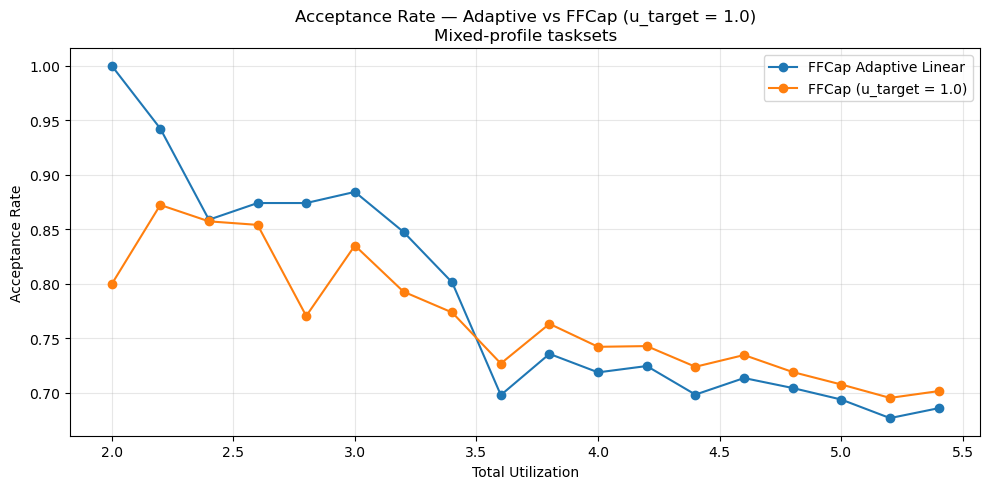

In [22]:
mixed_label_map = {
    "ff_cap_adaptive_linear": "FFCap Adaptive Linear",
    "ff_cap_u_target_1_0": "FFCap (u_target = 1.0)",
}

mixed_comparison_summary = (
    mixed_comparison_df.group_by(["allocator", "total_util"])
    .agg(
        acceptance_rate=1.0
        - pl.col("rejected_arrivals").sum() / pl.col("total_arrivals").sum(),
    )
    .sort(["allocator", "total_util"])
)

fig, ax = plt.subplots(figsize=(10, 5))
for name, label in mixed_label_map.items():
    data = mixed_comparison_summary.filter(pl.col("allocator") == name).sort("total_util")
    ax.plot(
        data["total_util"], data["acceptance_rate"],
        marker="o", linewidth=1.5, label=label,
    )

ax.set_xlabel("Total Utilization")
ax.set_ylabel("Acceptance Rate")
ax.set_title("Acceptance Rate — Adaptive vs FFCap (u_target = 1.0)\nMixed-profile tasksets")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Acceptance rate gain (Adaptive − FFCap) — mixed profile

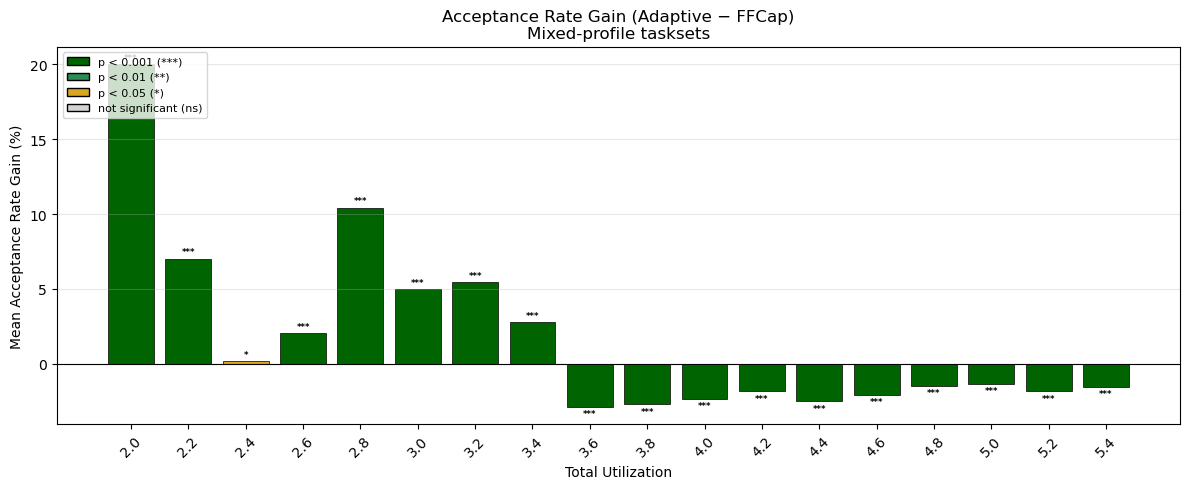

In [23]:
mixed_utils_arr = mixed_sig_df["total_util"].to_numpy()
mixed_gains_arr = mixed_sig_df["mean_gain_pct"].to_numpy()
mixed_sig_labels = mixed_sig_df["significance"].to_list()

SIG_COLORS_MIXED = {"***": "darkgreen", "**": "seagreen", "*": "goldenrod", "ns": "lightgray"}

fig, ax = plt.subplots(figsize=(12, 5))
colors_mixed = [SIG_COLORS_MIXED[s] for s in mixed_sig_labels]
bars = ax.bar(
    [f"{u:.1f}" for u in mixed_utils_arr], mixed_gains_arr,
    color=colors_mixed, edgecolor="black", linewidth=0.5,
)

for bar, label in zip(bars, mixed_sig_labels):
    y = bar.get_height()
    va = "bottom" if y >= 0 else "top"
    offset = 0.15 if y >= 0 else -0.15
    ax.text(bar.get_x() + bar.get_width() / 2, y + offset, label,
            ha="center", va=va, fontsize=6, fontweight="bold")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Total Utilization")
ax.set_ylabel("Mean Acceptance Rate Gain (%)")
ax.set_title("Acceptance Rate Gain (Adaptive − FFCap)\nMixed-profile tasksets")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, axis="y", alpha=0.3)

from matplotlib.patches import Patch
legend_elements_mixed = [
    Patch(facecolor="darkgreen", edgecolor="black", label="p < 0.001 (***)"),
    Patch(facecolor="seagreen", edgecolor="black", label="p < 0.01 (**)"),
    Patch(facecolor="goldenrod", edgecolor="black", label="p < 0.05 (*)"),
    Patch(facecolor="lightgray", edgecolor="black", label="not significant (ns)"),
]
ax.legend(handles=legend_elements_mixed, fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()